# Validation

## 1. Answer the questions

### **1.1 Leave-One-Out (LOO) Cross-Validation**

**Definition:**
Leave-One-Out (LOO) is a cross-validation method where the number of folds equals the number of samples in the dataset (k = n). In each iteration, the model is trained on all samples except one, and validated on that single sample. The process is repeated n times, and the final performance estimate is averaged across all iterations.

**Advantages:**
1.  **Efficient data usage:** In each iteration, almost the entire dataset (n-1 samples) is used for training. This is particularly valuable when the total amount of data is small, as we don't sacrifice a large portion of data for validation.
2.  **Deterministic:** Unlike random k-fold splitting, the LOO result (given a fixed data order) is always reproducible, as the process exhaustively iterates through all possible splits.

**Disadvantages and Limitations:**
1.  **High computational cost:** The model must be trained as many times as there are samples in the dataset. For large datasets (e.g., > 10,000 samples), this becomes practically infeasible due to enormous time and resource requirements.
2.  **High variance of the estimate:** The performance estimate at each individual step is based on just one sample, which is a very "noisy" measure. Consequently, the final averaged estimate may have high variance and be sensitive to outliers.
3.  **Not applicable for time series:** LOO violates the temporal structure of the data. If we train a model on future data to predict a past value, this leads to data leakage and makes the performance estimate invalid and optimistically biased. For time series, specialized methods like TimeSeriesSplit should be used.

### **1.2 Hyperparameter Optimization Methods**

**1. Grid Search**

**How it works:**
This is an exhaustive search method. We specify a fixed set of values (a grid) for each hyperparameter. The algorithm sequentially evaluates ALL possible combinations of these values. For each combination, a model is trained (usually with cross-validation) and its performance is measured. Finally, the combination with the best result is selected.

**Advantages:**
- Guarantees finding the best combination among the specified options
- Simple to implement and understand

**Disadvantages:**
- Very slow with a large number of parameters (exponential growth in the number of combinations)
- If the optimal value lies between grid points, it will be missed
- Wastes time evaluating obviously poor combinations

---

**2. Randomized Grid Search**

**How it works:**
Instead of exhaustive search, we specify distributions or lists of possible values for each parameter and randomly select a specified number of combinations. A key difference from Grid Search is the ability to use CONTINUOUS distributions (e.g., uniform from 0.01 to 1.0), allowing the algorithm to sample values from the entire continuous space rather than from fixed points.

**Advantages:**
- Controlled runtime (we specify the number of iterations)
- Can find a good solution faster than Grid Search
- Better explores the parameter space with continuous distributions

**Disadvantages:**
- No guarantee that the best combination has been evaluated
- Results are random and may vary between runs

---

**3. Bayesian Optimization**

**How it works:**
This is a more intelligent approach that uses the history of past evaluations to select the next points. The process is as follows:

1. A **surrogate model** (typically a Gaussian Process or TPE) is built, which predicts not only the expected performance for untested combinations but also the **uncertainty** of that prediction (confidence interval).
2. A special **acquisition function** balances between:
   - **Exploitation:** evaluating regions where the model has already shown good results
   - **Exploration:** evaluating regions with high uncertainty (where little is known)
3. The next point to evaluate is selected, the model is trained, and the result is added to the history.
4. The surrogate model is retrained with the new data.
5. The process repeats until a specified accuracy or iteration limit is reached.

**Advantages:**
- Requires fewer iterations to find a good solution
- Intelligently explores the parameter space
- Particularly effective when model training is expensive (in time/resources)

**Disadvantages:**
- More complex to implement
- Requires tuning of the Bayesian optimization's own hyperparameters
- Can get stuck in a local optimum

### **1.3 Feature Selection Methods**

#### Classification of Methods

**1. Filters**
- **How they work:** Evaluate features BEFORE model training at the preprocessing stage
- **Principle:** Each feature is evaluated in isolation (does not consider combinations)
- **Pros:** Very fast, scale to thousands of features
- **Cons:** Cannot see that two weak features together might create a strong effect
- **Examples:** Pearson correlation, Chi-square, mutual information

**2. Wrappers**
- **How they work:** Use the model as a "black box" to search through feature combinations
- **Principle:** Exhaustive search through different feature subsets with model performance evaluation
- **Pros:** Account for feature interactions
- **Cons:** Very slow (train model many times), risk of overfitting
- **Examples:** RFE (Recursive Feature Elimination), forward/backward selection

**3. Embedded Methods**
- **How they work:** Feature selection occurs DURING model training
- **Principle:** "Golden middle ground" — faster than wrappers but considers interactions better than filters
- **Pros:** Account for feature interactions, faster than wrappers
- **Cons:** Specific to particular model types
- **Examples:** Lasso (L1-regularization), Ridge, feature importance in trees

---

#### Specific Methods

**Pearson Correlation**

**What it measures:**
- Strength and direction of **linear** relationship between two continuous variables
- Values from -1 to 1:
  - 1 — perfect positive linear relationship
  - -1 — perfect negative linear relationship
  - 0 — no linear relationship

**Limitations:**
- Detects **only linear** dependencies
- Sensitive to outliers
- Requires approximately normal distribution
- Works only with numerical data

**Application in feature selection:**
- Keep features with high correlation with the target variable
- Remove features with high correlation among themselves (multicollinearity)

---

**Chi-square (Chi2)**

**For which data:**
- Works with **categorical** variables (or numerical after binarization)
- Target variable must also be categorical

**What it measures:**
- **Statistical dependence** between feature and target variable
- Tests the hypothesis of independence between feature and target
- Higher Chi2 value indicates stronger dependence (more important feature)

**Difference from Pearson:**
- Not sensitive to outliers (works with frequencies)
- Can detect **any type of dependency**, not just linear
- Requires sufficient observations in each category

**Important:** Chi2 does not show the strength or direction of relationship, only the presence of dependency

---

**Lasso (L1-regularization)**

**How it works:**
- Modified loss function: $Loss = MSE + α * Σ|wᵢ|$
- Penalty added for large coefficients (sum of absolute values)

**How it selects features:**
- Due to the nature of L1-regularization, many coefficients become **exactly zero**
- Larger α (regularization strength) leads to more features being zeroed out
- Non-zero coefficients remain only for important features

**Why Embedded:**
- Feature selection occurs **within the model training process**

**Important:** Lasso is sensitive to feature scale — normalization required!

---

**Permutation Importance**

**How it works (step by step):**
1. Train model and calculate baseline metric on validation set
2. For each feature sequentially:
   - Randomly **permute** the values of this feature
   - Recalculate the metric
   - Drop in performance = feature importance
3. Restore data to original state

**Why this is a "fair" estimate:**
- Works with any model ("black box")
- Shows the feature's real contribution
- Accounts for interaction with other features

**Caution:**
- With highly correlated features, the effect may be underestimated
- Requires many prediction runs (more computationally expensive)

---

**SHAP (SHapley Additive exPlanations)**

**Origin of the name:**
- Comes from **cooperative game theory** (Shapley values)
- Features are "players," prediction is the "payout"

**How it works:**
- Takes a **base value** — the average prediction across the dataset
- For each instance, SHAP shows how each feature **shifted** the prediction relative to the base
- Sum of all feature contributions + base value = final prediction

**What it shows:**
- **Direction of influence:** positive = increased prediction, negative = decreased prediction
- **Strength of influence:** absolute value
- Can be aggregated across all instances for global importance

**Why SHAP is great:**
- Unified theory for any model
- Local + global interpretation
- Accounts for feature interactions
- Consistent — if a feature becomes more important, its SHAP value will not decrease

## 2. Inroduction

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import optuna

import shap

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GroupKFold

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error


/Users/dataalph/goinfre/conda_envs/ml_project_10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from my_utils import process_features_complete, add_model_results, add_model_results_cv, r2_score

In [3]:
df_train = pd.read_json("data/train.json")
df_test = pd.read_json("data/test.json")
df = pd.concat([df_train, df_test], ignore_index=True)
df.to_json("data/result.json", index=False)

In [4]:
df = pd.read_json('data/result.json')

In [5]:
df.head(3)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
0,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
1,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
2,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium


In [6]:
percentile_1 = np.percentile(df["price"], 1)
percentile_99 = np.percentile(df["price"], 99)
df = df[(df["price"] >= percentile_1) & (df["price"] <= percentile_99)].copy()
df = df[(df["bathrooms"] < 10)].copy()

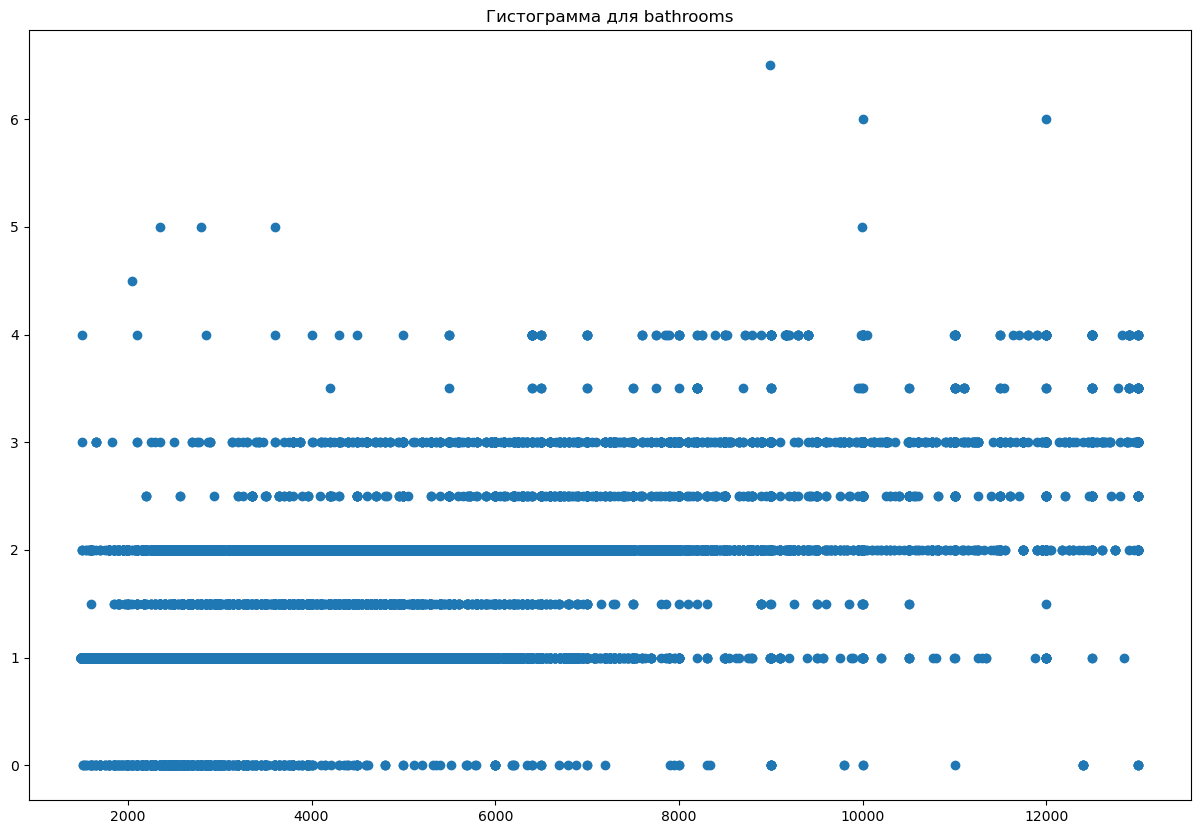

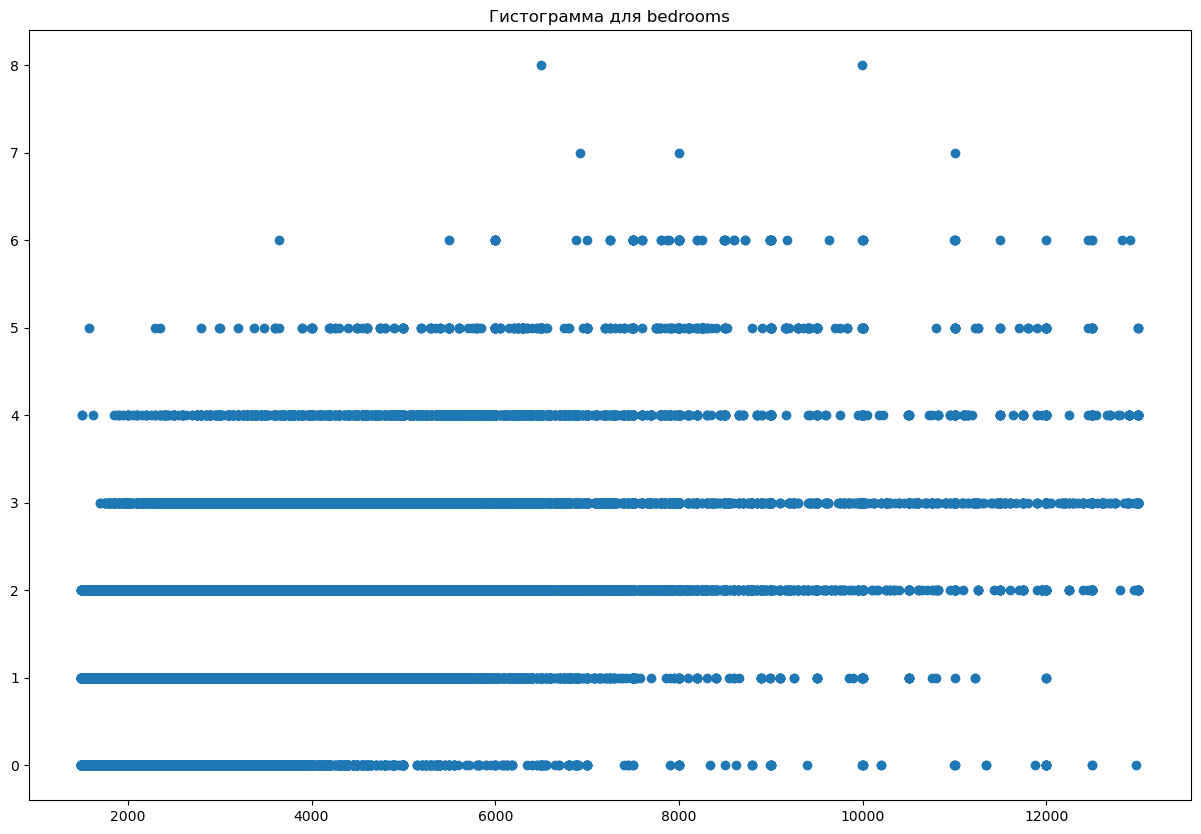

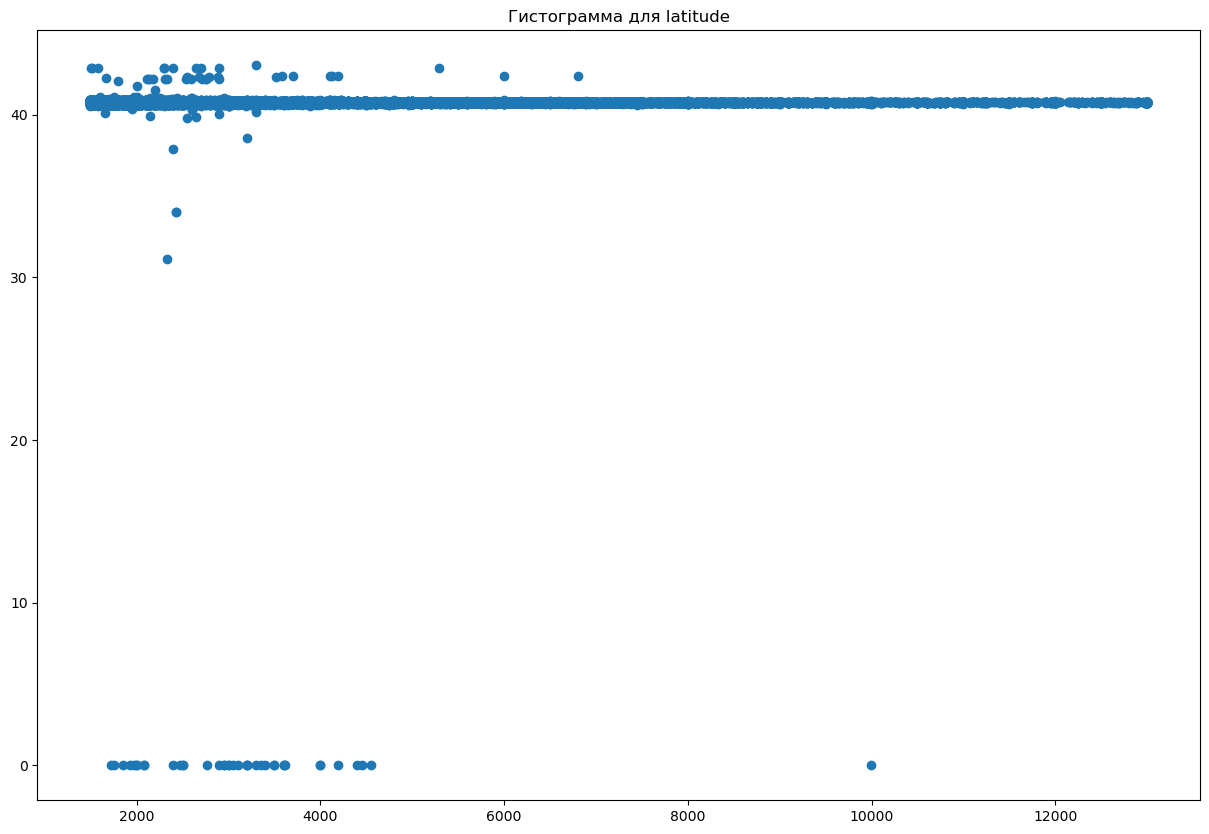

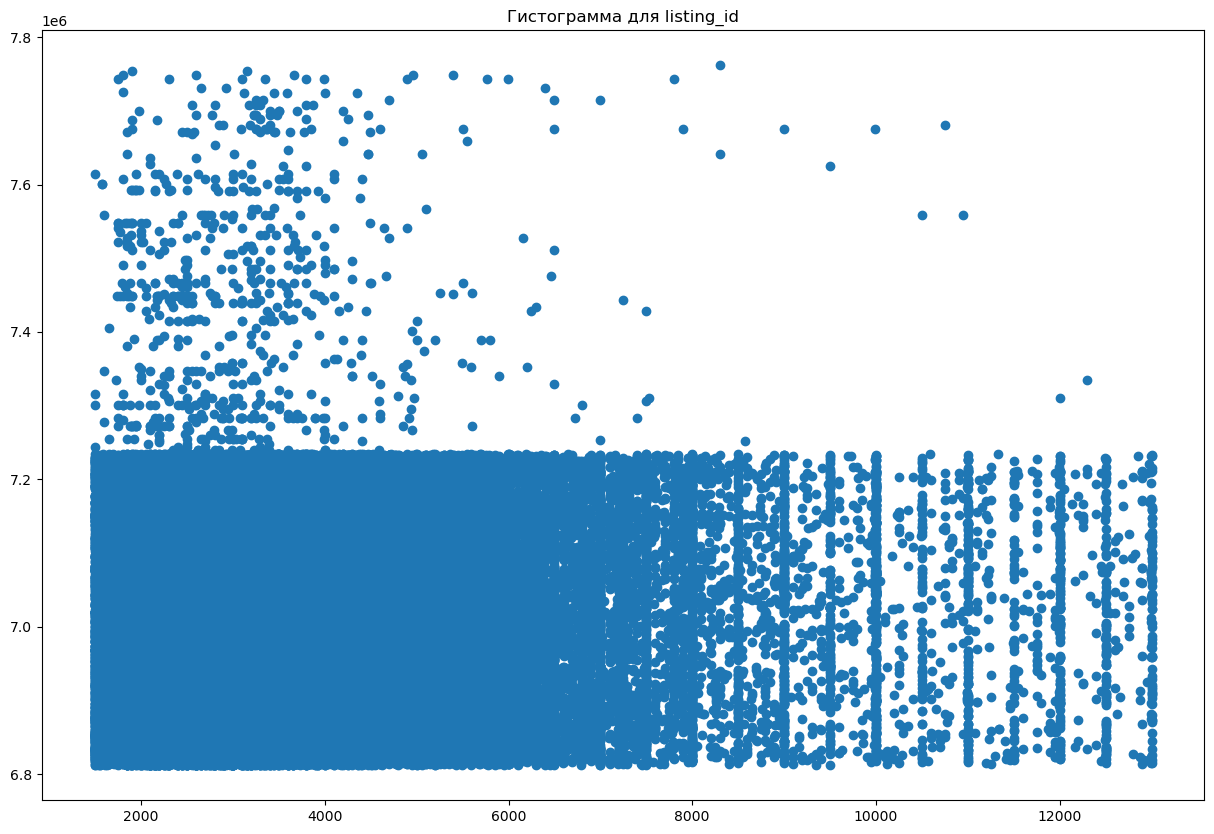

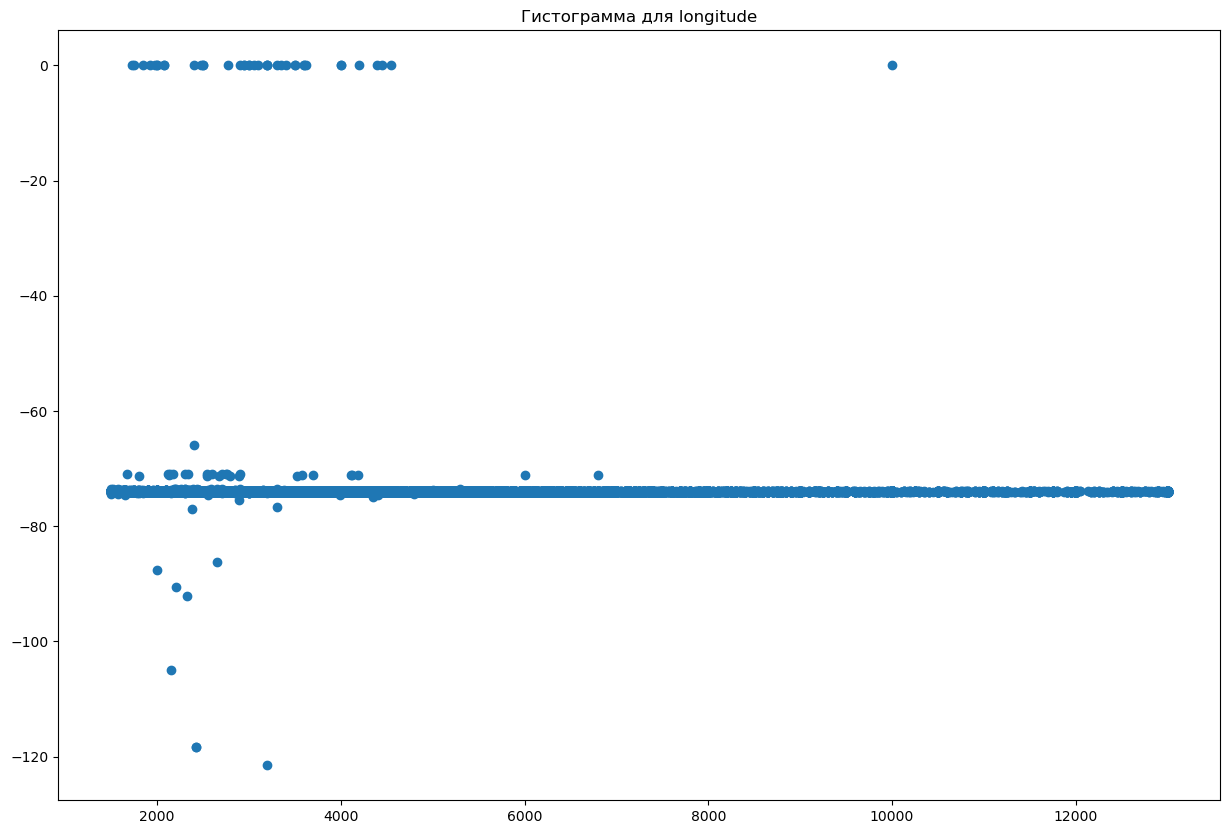

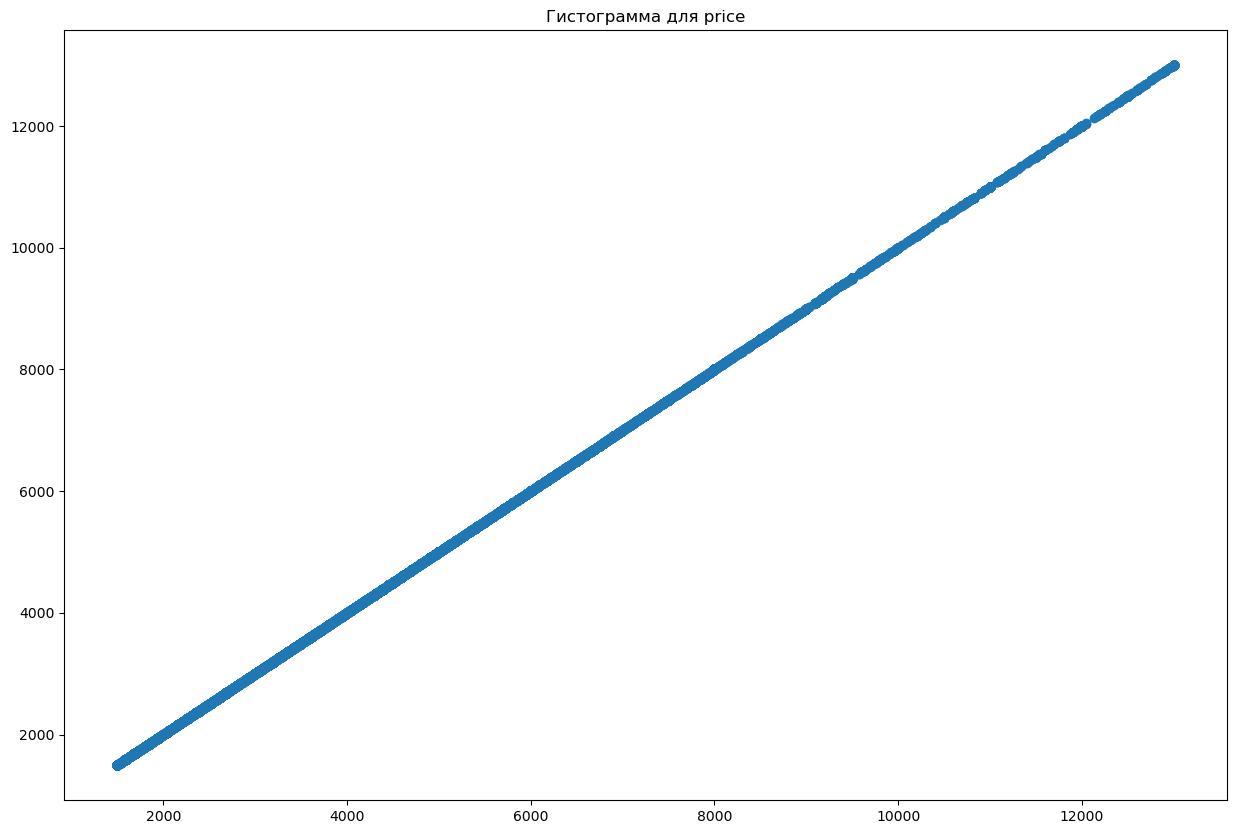

In [7]:
for column in df.select_dtypes(include=["number"]).columns:
    plt.figure(figsize=(15, 10))
    plt.scatter(df["price"], df[column])
    plt.title(f"Гистограмма для {column}")
    plt.show()

In [8]:
df["price"].describe()

count    121573.000000
mean       3535.034054
std        1593.047421
min        1495.000000
25%        2500.000000
50%        3150.000000
75%        4077.000000
max       13000.000000
Name: price, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x16d3a9870>,
 'caps': [<matplotlib.lines.Line2D at 0x17b2ea800>,
 'boxes': [<matplotlib.lines.Line2D at 0x16d61fe80>],
 'medians': [<matplotlib.lines.Line2D at 0x17b2eb490>],
 'fliers': [<matplotlib.lines.Line2D at 0x17b2eb1c0>],
 'means': []}

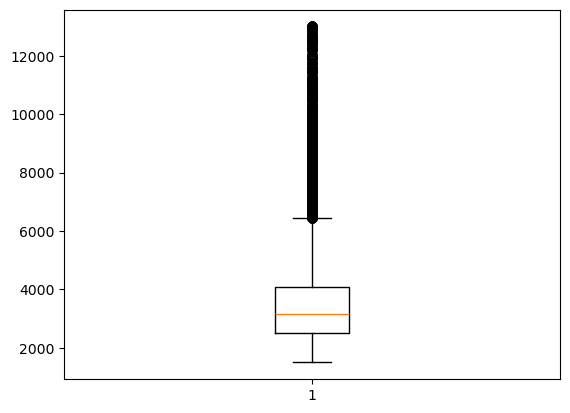

In [9]:
plt.boxplot(df["price"])

In [10]:
X = process_features_complete(df)
y = X["price"].copy()
X = X.drop(columns=["price"])

In [11]:
X_without_data = X.drop(columns=["created"])

## 3. Split data

### 3.1 Split data into 2 parts randomly

In [12]:
def random_split(X, y, test_size=0.2, random_state=None):
    """
    Random split into train and test parts.

    Parameters:
    -----------
    X : pd.DataFrame or np.array
    y : pd.Series or np.array
    test_size : float (0-1)
    random_state : int or None

    Returns:
    --------
    X_train, X_test, y_train, y_test
    """

    if random_state is not None:
        np.random.seed(random_state)

    n_samples = len(X)
    indices = np.arange(n_samples)

    np.random.shuffle(indices)

    split_point = int(n_samples * (1 - test_size))

    train_idx = indices[:split_point]
    test_idx = indices[split_point:]

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    return X_train, X_test, y_train, y_test

### 3.2 Split data into 3 parts randomly

In [13]:
def random_split_3(X, y, validation_size=0.2, test_size=0.2, random_state=None):
    """
    Random split into train / validation / test.

    Parameters
    ----------
    X : pd.DataFrame
    y : pd.Series
    validation_size : float
    test_size : float
    random_state : int or None

    Returns
    -------
    X_train, X_valid, X_test, y_train, y_valid, y_test
    """

    if validation_size + test_size >= 1:
        raise ValueError("validation_size + test_size must be < 1")

    if random_state is not None:
        np.random.seed(random_state)

    n_samples = len(X)
    indices = np.arange(n_samples)

    np.random.shuffle(indices)

    train_end = int(n_samples * (1 - validation_size - test_size))
    valid_end = int(n_samples * (1 - test_size))

    train_idx = indices[:train_end]
    valid_idx = indices[train_end:valid_end]
    test_idx = indices[valid_end:]

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]
    y_test = y.iloc[test_idx]

    return X_train, X_valid, X_test, y_train, y_valid, y_test

### 3.3 Split data into 2 parts with parametr date_split

In [14]:
def date_split(X, y, date_field, date_split):
    """
    Out-of-time split into train and test.

    Parameters
    ----------
    X : pd.DataFrame
    y : pd.Series
    date_field : str
    date_split : str or pd.Timestamp

    Returns
    -------
    X_train, X_test, y_train, y_test
    """

    X = X.copy()

    X[date_field] = pd.to_datetime(X[date_field])
    date_split = pd.to_datetime(date_split)

    X = X.sort_values(date_field)
    y = y.loc[X.index]

    train_mask = X[date_field] <= date_split
    test_mask = X[date_field] > date_split

    X_train = X.loc[train_mask]
    X_test = X.loc[test_mask]

    y_train = y.loc[train_mask]
    y_test = y.loc[test_mask]

    return X_train, X_test, y_train, y_test

### 3.4 Split data into 3 parts with parametrs validation_date, test_date

In [15]:
def date_split_3(X, y, date_field, validation_date, test_date):
    """
    Out-of-time split into train / validation / test
    using fixed date boundaries.

    Parameters
    ----------
    X : pd.DataFrame
    y : pd.Series
    date_field : str
    validation_date : str or pd.Timestamp
    test_date : str or pd.Timestamp

    Returns
    -------
    X_train, X_valid, X_test,
    y_train, y_valid, y_test
    """

    if pd.to_datetime(validation_date) >= pd.to_datetime(test_date):
        raise ValueError("validation_date must be earlier than test_date")

    X = X.copy()
    X[date_field] = pd.to_datetime(X[date_field])

    validation_date = pd.to_datetime(validation_date)
    test_date = pd.to_datetime(test_date)

    X = X.sort_values(date_field)
    y = y.loc[X.index]

    train_mask = X[date_field] <= validation_date
    valid_mask = (X[date_field] > validation_date) & (X[date_field] <= test_date)
    test_mask = X[date_field] > test_date

    X_train = X.loc[train_mask]
    X_valid = X.loc[valid_mask]
    X_test = X.loc[test_mask]

    y_train = y.loc[train_mask]
    y_valid = y.loc[valid_mask]
    y_test = y.loc[test_mask]

    return X_train, X_valid, X_test, y_train, y_valid, y_test

## **What does determenistic meain?**

A deterministic function returns the same result every time if the input parameters are the same.

## 4. Cross-validation methods

### 4.1 K-Fold

![kfold](../misc/images/my_kfold.png)

In [16]:
def k_fold_split(n_samples, k=5, shuffle=True, random_state=None):
    """
    Custom K-Fold implementation. Provides train/test indices to split data in train/test sets. Split dataset into k consecutive folds.

    Parameters
    ----------
    n_samples : int
    k : int
    shuffle : bool
    random_state : int or None

    Returns
    -------
    folds : list of (train_idx, test_idx)
    """

    if k <= 1:
        raise ValueError("k must be at least 2")

    indices = np.arange(n_samples)

    if shuffle:
        if random_state is not None:
            np.random.seed(random_state)
        np.random.shuffle(indices)

    fold_sizes = np.full(k, n_samples // k)
    fold_sizes[: n_samples % k] += 1

    folds = []
    current = 0

    for fold_size in fold_sizes:
        start, stop = current, current + fold_size

        test_idx = indices[start:stop]
        train_idx = np.concatenate((indices[:start], indices[stop:]))

        folds.append((train_idx, test_idx))

        current = stop

    return folds

### 4.2 Grouped K-Fold

![gkf](../misc/images/1.png)

In [17]:
def group_k_fold_split(groups, k=5, shuffle=True, random_state=None):
    """
    Custom Group K-Fold implementation. K-fold iterator variant with non-overlapping groups. 
    Each group will appear exactly once in the test set across all folds.

    Parameters
    ----------
    groups : array-like (group id for each sample)
    k : int
    shuffle : bool
    random_state : int or None

    Returns
    -------
    folds : list of (train_idx, test_idx)
    """

    groups = np.array(groups)
    unique_groups = np.unique(groups)

    if k > len(unique_groups):
        raise ValueError("k cannot be greater than number of unique groups")

    if shuffle:
        if random_state is not None:
            np.random.seed(random_state)
        np.random.shuffle(unique_groups)

    group_fold_sizes = np.full(k, len(unique_groups) // k)
    group_fold_sizes[: len(unique_groups) % k] += 1

    folds = []
    current = 0

    for fold_size in group_fold_sizes:
        start, stop = current, current + fold_size

        test_groups = unique_groups[start:stop]

        test_mask = np.isin(groups, test_groups)
        test_idx = np.where(test_mask)[0]
        train_idx = np.where(~test_mask)[0]

        folds.append((train_idx, test_idx))

        current = stop

    return folds

### 4.3 Stratified K-Fold

![gkf](../misc/images/3.png)

In [18]:
def stratified_k_fold_split(y, k=5, shuffle=True, random_state=None):
    """
    Custom Stratified K-Fold implementation. This cross-validation object is a variation of KFold that returns stratified folds. 
    The folds are made by preserving the percentage of samples for each class in y in a binary or multiclass classification setting.

    Parameters
    ----------
    y : array-like (target)
    k : int
    shuffle : bool
    random_state : int or None

    Returns
    -------
    folds : list of (train_idx, test_idx)
    """

    y = np.array(y)
    unique_classes = np.unique(y)

    if shuffle and random_state is not None:
        np.random.seed(random_state)

    class_indices = {}

    for cls in unique_classes:
        idx = np.where(y == cls)[0]
        if shuffle:
            np.random.shuffle(idx)
        class_indices[cls] = idx

    folds = [[] for _ in range(k)]

    for cls, idx in class_indices.items():
        split_indices = np.array_split(idx, k)
        for fold_id in range(k):
            folds[fold_id].extend(split_indices[fold_id])

    result = []

    all_indices = np.arange(len(y))

    for fold_id in range(k):
        test_idx = np.array(folds[fold_id])
        train_idx = np.setdiff1d(all_indices, test_idx)
        result.append((train_idx, test_idx))

    return result

### 4.4 Time series split

![gkf](../misc/images/4.png)

In [19]:
def time_series_split(X, date_field, k=5):
    """
    Custom Time Series Split (expanding window). Performs expanding window time series cross-validation splitting. 
    Unlike standard cross-validation, this method respects chronological order — training data always precedes test data temporally, 
    preventing future information leakage.

    Parameters
    ----------
    X : pd.DataFrame
    date_field : str
    k : int

    Returns
    -------
    folds : list of (train_idx, test_idx)
    """

    if k < 2:
        raise ValueError("k must be at least 2")

    X_sorted = X.sort_values(date_field).reset_index(drop=True)

    n = len(X_sorted)
    folds = []

    for i in range(1, k):
        train_end = int(n * i / k)
        test_end = int(n * (i + 1) / k) if i < k - 1 else n

        if train_end >= n:
            train_end = n - 1

        train_idx = X_sorted.index[:train_end].to_numpy()
        test_idx = X_sorted.index[train_end:test_end].to_numpy()

        if len(train_idx) > 0 and len(test_idx) > 0:
            folds.append((train_idx, test_idx))
        else:
            print(f"Warning: Empty fold detected. Reducing effective k to {i}")
            break

    return folds

## 5 Cross-validation comparison

In [20]:
result_MAE = pd.DataFrame(
    {
        "model": pd.Series(dtype="str"),
        "train": pd.Series(dtype="float"),
        "test": pd.Series(dtype="float"),
    }
)

result_RMSE = pd.DataFrame(
    {
        "model": pd.Series(dtype="str"),
        "train": pd.Series(dtype="float"),
        "test": pd.Series(dtype="float"),
    }
)

result_R2 = pd.DataFrame(
    {
        "model": pd.Series(dtype="str"),
        "train": pd.Series(dtype="float"),
        "test": pd.Series(dtype="float"),
    }
)

In [21]:
result_MAE_sklearn = pd.DataFrame(
    {
        "model": pd.Series(dtype="str"),
        "train": pd.Series(dtype="float"),
        "test": pd.Series(dtype="float"),
    }
)

result_RMSE_sklearn = pd.DataFrame(
    {
        "model": pd.Series(dtype="str"),
        "train": pd.Series(dtype="float"),
        "test": pd.Series(dtype="float"),
    }
)

result_R2_sklearn = pd.DataFrame(
    {
        "model": pd.Series(dtype="str"),
        "train": pd.Series(dtype="float"),
        "test": pd.Series(dtype="float"),
    }
)

In [22]:
model_lr = LinearRegression()

### 5.1 Split random

In [23]:
X_train, X_test, y_train, y_test = random_split(
    X_without_data, y, test_size=0.2, random_state=42
)

result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE,
    result_RMSE,
    result_R2,
    model_lr,
    "LinearRegression_RandomSplit",
    X_train,
    X_test,
    y_train,
    y_test,
)

### 5.2 Date split

In [24]:
X_sorted = X.copy()
X_sorted["created"] = pd.to_datetime(X_sorted["created"])
X_sorted = X_sorted.sort_values("created")

n = len(X_sorted)

train_end = int(n * 0.8)
validation_date = X_sorted["created"].iloc[train_end]

# print("validation_date:", validation_date)

X_train, X_test, y_train, y_test = date_split(
    X, y, date_field="created", date_split=validation_date
)

X_train = X_train.drop(columns=["created"])
X_test = X_test.drop(columns=["created"])

In [25]:
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE,
    result_RMSE,
    result_R2,
    model_lr,
    "LinearRegression_DateSplit",
    X_train,
    X_test,
    y_train,
    y_test,
)

### 5.3  K-Fold

In [26]:
folds_k = k_fold_split(len(X_without_data), k=5, shuffle=True, random_state=21)

In [27]:
result_MAE, result_RMSE, result_R2 = add_model_results_cv(
    result_MAE,
    result_RMSE,
    result_R2,
    model_lr,
    "LinearRegression_KFold",
    X_without_data,
    y,
    folds_k,
)

### 5.3  GroupKFold

There are no suitable features, so we’ll create a new one.

In [28]:
X_with_new = X_without_data.copy()

amenities = [
    "Elevator",
    "Doorman",
    "FitnessCenter",
    "LaundryinUnit",
    "RoofDeck",
    "Dishwasher",
]
X_with_new["amenity_level"] = X_with_new[amenities].sum(axis=1)
X_with_new["group_key"] = (
    X_with_new["bedrooms"].astype(str)
    + "_"
    + X_with_new["bathrooms"].astype(str)
    + "_"
    + X_with_new["amenity_level"].astype(str)
)
X_with_new["group_key"].nunique()

268

In [29]:
groups = np.array(X_with_new["group_key"].unique())

In [30]:
folds_gk = group_k_fold_split(groups, k=5, shuffle=True, random_state=21)

In [31]:
result_MAE, result_RMSE, result_R2 = add_model_results_cv(
    result_MAE,
    result_RMSE,
    result_R2,
    model=model_lr,
    model_name="LinearRegression_GroupKFold",
    X=X_without_data,
    y=y,
    folds=folds_gk,
)

### 5.5  StratifiedKFold

In [32]:
y_strat = pd.qcut(y, q=5, labels=False)
folds_s = stratified_k_fold_split(y=y_strat, k=5, shuffle=True, random_state=21)

In [33]:
result_MAE, result_RMSE, result_R2 = add_model_results_cv(
    result_MAE,
    result_RMSE,
    result_R2,
    model=model_lr,
    model_name="LinearRegression_Stratified",
    X=X_without_data,
    y=y,
    folds=folds_s,
)

### 5.6 TimeSeriesSplit

In [34]:
folds_t = time_series_split(X, date_field="created", k=5)

In [35]:
result_MAE, result_RMSE, result_R2 = add_model_results_cv(
    result_MAE,
    result_RMSE,
    result_R2,
    model=model_lr,
    model_name="LinearRegression_TimeSeries",
    X=X_without_data,
    y=y,
    folds=folds_t,
)

### 5.7 sklearn

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X_without_data, y, test_size=0.2, random_state=21
)

result_MAE_sklearn, result_RMSE_sklearn, result_R2_sklearn = add_model_results(
    result_MAE_sklearn,
    result_RMSE_sklearn,
    result_R2_sklearn,
    model_lr,
    "LinearRegression_RandomSplit_sklearn",
    X_train,
    X_test,
    y_train,
    y_test,
)

 There are no direct analogs for date_split

In [37]:
kf = KFold(n_splits=5, shuffle=True, random_state=21)
folds_k = list(kf.split(X_without_data))

result_MAE_sklearn, result_RMSE_sklearn, result_R2_sklearn = add_model_results_cv(
    result_MAE_sklearn,
    result_RMSE_sklearn,
    result_R2_sklearn,
    model=model_lr,
    model_name="LinearRegression_KFold_sklearn",
    X=X_without_data,
    y=y,
    folds=folds_k,
)

In [38]:
gkf = GroupKFold(n_splits=5, shuffle=True)
folds_gk_s = list(gkf.split(X=X_without_data, y=y, groups=X_with_new["group_key"]))

result_MAE_sklearn, result_RMSE_sklearn, result_R2_sklearn = add_model_results_cv(
    result_MAE_sklearn,
    result_RMSE_sklearn,
    result_R2_sklearn,
    model=model_lr,
    model_name="LinearRegression_GroupKFold_sklearn",
    X=X_without_data,
    y=y,
    folds=folds_gk_s,
)

In [39]:
y_strat = pd.qcut(y, q=5, labels=False)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)
folds_s = list(skf.split(X_without_data, y_strat))

result_MAE_sklearn, result_RMSE_sklearn, result_R2_sklearn = add_model_results_cv(
    result_MAE_sklearn,
    result_RMSE_sklearn,
    result_R2_sklearn,
    model=model_lr,
    model_name="LinearRegression_Stratified_sklearn",
    X=X_without_data,
    y=y,
    folds=folds_s,
)

In [40]:
tscv = TimeSeriesSplit(n_splits=5)
folds_t = list(tscv.split(X))

result_MAE_sklearn, result_RMSE_sklearn, result_R2_sklearn = add_model_results_cv(
    result_MAE_sklearn,
    result_RMSE_sklearn,
    result_R2_sklearn,
    model=model_lr,
    model_name="LinearRegression_TimeSeries_sklearn",
    X=X_without_data,
    y=y,
    folds=folds_t,
)

### 5.8 Results

#### **MAE**

In [41]:
result_MAE

,model,train,test
0,LinearRegression_RandomSplit,713.182526,711.778952
1,LinearRegression_DateSplit,708.750039,726.065117
2,LinearRegression_KFold,712.438054,712.627864
3,LinearRegression_GroupKFold,672.112470,763.847505
4,LinearRegression_Stratified,712.432439,712.593906
5,LinearRegression_TimeSeries,713.540470,712.964374


In [42]:
result_MAE_sklearn

,model,train,test
0,LinearRegression_RandomSplit_sklearn,713.392358,710.173082
1,LinearRegression_KFold_sklearn,712.438054,712.627864
2,LinearRegression_GroupKFold_sklearn,712.207725,731.874090
3,LinearRegression_Stratified_sklearn,712.434141,712.585510
4,LinearRegression_TimeSeries_sklearn,712.635956,713.025796


In [43]:
print(
    f"The best in test MAE: {result_MAE.loc[result_MAE['test'].idxmin(), 'model']} {result_MAE['test'].min()}"
)

result_MAE["difference"] = abs(result_MAE["train"] - result_MAE["test"])
min_diff_model = result_MAE.loc[result_MAE["difference"].idxmin(), "model"]
min_diff_value = result_MAE["difference"].min()

print(f"The most stable model by MAE: {min_diff_model} {min_diff_value:.4f}")

The best in test MAE: LinearRegression_RandomSplit 711.7789522790478
The most stable model by MAE: LinearRegression_Stratified 0.1615


In [44]:
print(
    f"The best in test MAE (sklearn): {result_MAE_sklearn.loc[result_MAE_sklearn['test'].idxmin(), 'model']} {result_MAE_sklearn['test'].min()}"
)

result_MAE_sklearn["difference"] = abs(
    result_MAE_sklearn["train"] - result_MAE_sklearn["test"]
)
min_diff_model_sklearn = result_MAE_sklearn.loc[
    result_MAE_sklearn["difference"].idxmin(), "model"
]
min_diff_value_sklearn = result_MAE_sklearn["difference"].min()

print(
    f"The most stable model by MAE (sklearn): {min_diff_model_sklearn} {min_diff_value_sklearn:.4f}"
)

The best in test MAE (sklearn): LinearRegression_RandomSplit_sklearn 710.1730818930815
The most stable model by MAE (sklearn): LinearRegression_Stratified_sklearn 0.1514


#### **RMSE**

In [45]:
result_RMSE

,model,train,test
0,LinearRegression_RandomSplit,1034.679215,1024.521092
1,LinearRegression_DateSplit,1030.873975,1040.124777
2,LinearRegression_KFold,1032.580904,1032.880372
3,LinearRegression_GroupKFold,946.348796,1106.201753
4,LinearRegression_Stratified,1032.592843,1032.835265
5,LinearRegression_TimeSeries,1032.098830,1031.911381


In [46]:
result_RMSE_sklearn

,model,train,test
0,LinearRegression_RandomSplit_sklearn,1036.515327,1017.058885
1,LinearRegression_KFold_sklearn,1032.580904,1032.880372
2,LinearRegression_GroupKFold_sklearn,1032.524256,1055.803679
3,LinearRegression_Stratified_sklearn,1032.594942,1032.834091
4,LinearRegression_TimeSeries_sklearn,1029.530118,1032.226874


In [47]:
print(
    f"The best in test RMSE: {result_RMSE.loc[result_RMSE['test'].idxmin(), 'model']} {result_RMSE['test'].min()}"
)

result_RMSE["difference"] = abs(result_RMSE["train"] - result_RMSE["test"])
min_diff_model = result_RMSE.loc[result_RMSE["difference"].idxmin(), "model"]
min_diff_value = result_RMSE["difference"].min()

print(f"The most stable model by RMSE: {min_diff_model} {min_diff_value:.4f}")

The best in test RMSE: LinearRegression_RandomSplit 1024.5210917398917
The most stable model by RMSE: LinearRegression_TimeSeries 0.1874


In [48]:
print(
    f"The best in test RMSE (sklearn): {result_RMSE_sklearn.loc[result_RMSE_sklearn['test'].idxmin(), 'model']} {result_RMSE_sklearn['test'].min()}"
)

result_RMSE_sklearn["difference"] = abs(
    result_RMSE_sklearn["train"] - result_RMSE_sklearn["test"]
)
min_diff_model_sklearn = result_RMSE_sklearn.loc[
    result_RMSE_sklearn["difference"].idxmin(), "model"
]
min_diff_value_sklearn = result_RMSE_sklearn["difference"].min()

print(
    f"The most stable model by RMSE (sklearn): {min_diff_model_sklearn} {min_diff_value_sklearn:.4f}"
)

The best in test RMSE (sklearn): LinearRegression_RandomSplit_sklearn 1017.0588847182283
The most stable model by RMSE (sklearn): LinearRegression_Stratified_sklearn 0.2391


#### **R2**

In [49]:
result_R2

,model,train,test
0,LinearRegression_RandomSplit,0.580022,0.578885
1,LinearRegression_DateSplit,0.580486,0.576764
2,LinearRegression_KFold,0.579852,0.579498
3,LinearRegression_GroupKFold,0.612014,0.459550
4,LinearRegression_Stratified,0.579845,0.579579
5,LinearRegression_TimeSeries,0.583548,0.577729


In [50]:
result_R2_sklearn

,model,train,test
0,LinearRegression_RandomSplit_sklearn,0.580481,0.576892
1,LinearRegression_KFold_sklearn,0.579852,0.579498
2,LinearRegression_GroupKFold_sklearn,0.579985,0.562295
3,LinearRegression_Stratified_sklearn,0.579847,0.579628
4,LinearRegression_TimeSeries_sklearn,0.584485,0.578505


In [51]:
print(f"The best in test R2: {result_R2.loc[result_R2['test'].idxmax(), 'model']}")

result_R2["difference"] = abs(result_R2["train"] - result_R2["test"])
min_diff_model = result_R2.loc[result_R2["difference"].idxmin(), "model"]
min_diff_value = result_R2["difference"].min()

print(f"The most stable model by R2: {min_diff_model} {min_diff_value:.4f}")

The best in test R2: LinearRegression_Stratified
The most stable model by R2: LinearRegression_Stratified 0.0003


In [52]:
print(
    f"The best in test R2 (sklearn): {result_R2_sklearn.loc[result_R2_sklearn['test'].idxmax(), 'model']}"
)

result_R2_sklearn["difference"] = abs(
    result_R2_sklearn["train"] - result_R2_sklearn["test"]
)
min_diff_model = result_R2_sklearn.loc[
    result_R2_sklearn["difference"].idxmin(), "model"
]
min_diff_value = result_R2_sklearn["difference"].min()

print(f"The most stable model by R2 (sklearn): {min_diff_model} {min_diff_value:.4f}")

The best in test R2 (sklearn): LinearRegression_Stratified_sklearn
The most stable model by R2 (sklearn): LinearRegression_Stratified_sklearn 0.0002


**MAE**
- The best in test MAE: LinearRegression_RandomSplit 711.7789522790478
- The most stable model by MAE: LinearRegression_Stratified 0.1615
- The best in test MAE (sklearn): LinearRegression_RandomSplit_sklearn 710.1730818930815
- The most stable model by MAE (sklearn): LinearRegression_Stratified_sklearn 0.1514

**RMSE**
- The best in test RMSE: LinearRegression_RandomSplit 1024.5210917398917
- The most stable model by RMSE: LinearRegression_TimeSeries 0.1874
- The best in test RMSE (sklearn): LinearRegression_RandomSplit_sklearn 1017.0588847182283
- The most stable model by RMSE (sklearn): LinearRegression_Stratified_sklearn 0.2391

**R2**
- The best in test R2: LinearRegression_Stratified
- The most stable model by R2: LinearRegression_Stratified 0.0003
- The best in test R2 (sklearn): LinearRegression_Stratified_sklearn
- The most stable model by R2 (sklearn): LinearRegression_Stratified_sklearn 0.0002

Based on the comparative analysis of validation schemes, Stratified K-Fold cross-validation (LinearRegression_Stratified_sklearn) is selected as the optimal approach. GroupKFold shows clear signs of overfitting (Train R²: 0.612 vs Test R²: 0.460), the Stratified approach provides the best balance between predictive accuracy and stability. It achieves the highest Test R² score (0.5796) and the lowest Test MAE (712.59) among robust models. Furthermore, it exhibits the lowest variance in cross-validation (stability delta of 0.0002), confirming it as the most reliable model for generalization on unseen data.

## 6 Feature Selection

In [53]:
df_results_mae = pd.DataFrame(columns=["model", "train", "valid", "test"])
df_results_rmse = pd.DataFrame(columns=["model", "train", "valid", "test"])
df_results_r2 = pd.DataFrame(columns=["model", "train", "valid", "test"])

### 6.1 Lasso regression model

In [54]:
X_train, X_valid, X_test, y_train, y_valid, y_test = random_split_3(
    X=X_without_data, y=y, validation_size=0.2, test_size=0.2, random_state=21
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

model_lasso = Lasso(random_state=21)
model_lasso.fit(X_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,21
,selection,'cyclic'


In [55]:
def evaluate_and_update(
    df_mae,
    df_rmse,
    df_r2,
    model,
    model_name,
    X_train,
    X_valid,
    X_test,
    y_train,
    y_valid,
    y_test,
):

    y_pred_train = model.predict(X_train)
    y_pred_valid = model.predict(X_valid)
    y_pred_test = model.predict(X_test)

    df_mae.loc[len(df_mae)] = [
        model_name,
        mean_absolute_error(y_train, y_pred_train),
        mean_absolute_error(y_valid, y_pred_valid),
        mean_absolute_error(y_test, y_pred_test),
    ]

    df_rmse.loc[len(df_rmse)] = [
        model_name,
        root_mean_squared_error(y_train, y_pred_train),
        root_mean_squared_error(y_valid, y_pred_valid),
        root_mean_squared_error(y_test, y_pred_test),
    ]

    df_r2.loc[len(df_r2)] = [
        model_name,
        r2_score(y_train, y_pred_train),
        r2_score(y_valid, y_pred_valid),
        r2_score(y_test, y_pred_test),
    ]

    return df_mae, df_rmse, df_r2

In [56]:
df_results_mae, df_results_rmse, df_results_r2 = evaluate_and_update(
    df_results_mae,
    df_results_rmse,
    df_results_r2,
    model_lasso,
    "Lasso",
    X_train_scaled,
    X_valid_scaled,
    X_test_scaled,
    y_train,
    y_valid,
    y_test,
)

### 6.2 Lasso regression model with top 10 features

In [57]:
coefficients = model_lasso.coef_
print(len(coefficients))
coefficients

22


array([114.08132819, -23.76874301, -82.50550474,  58.41699649,
       296.14262902,  75.70506172, -87.56240224, -91.98702061,
       108.54743217, -10.85853566, 173.46969635, -28.22969756,
       -19.44081216,  28.87980099, -61.01086104, -10.1416188 ,
        -0.        , -80.21913906, -28.44776252,  31.19218968,
       733.60542114, 489.15529835])

In [58]:
features_importance = pd.DataFrame({"feature": X_train.columns, "coef": coefficients})

features_importance["abs_coef"] = np.abs(features_importance["coef"])
features_importance_sorted = features_importance.sort_values(
    "abs_coef", ascending=False
)
features_importance_sorted.head(10)

,feature,coef,abs_coef
20,bathrooms,733.605421,733.605421
21,bedrooms,489.155298,489.155298
4,Doorman,296.142629,296.142629
10,LaundryinUnit,173.469696,173.469696
0,Elevator,114.081328,114.081328
8,FitnessCenter,108.547432,108.547432
7,LaundryinBuilding,-91.987021,91.987021
6,NoFee,-87.562402,87.562402
2,HardwoodFloors,-82.505505,82.505505
17,LaundryInBuilding,-80.219139,80.219139


In [59]:
top_10_features = features_importance_sorted.head(10)["feature"].tolist()
X_train_top_10 = X_train[top_10_features].copy()
X_valid_top_10 = X_valid[top_10_features].copy()
X_test_top_10 = X_test[top_10_features].copy()

scaler_top_10 = StandardScaler()
X_train_scaled_top_10 = scaler_top_10.fit_transform(X_train_top_10)
X_valid_scaled_top_10 = scaler_top_10.transform(X_valid_top_10)
X_test_scaled_top_10 = scaler_top_10.transform(X_test_top_10)

model_lasso_top_10 = Lasso(random_state=21)
model_lasso_top_10.fit(X_train_scaled_top_10, y_train)
y_pred_top_10 = model_lasso_top_10.predict(X_valid_scaled_top_10)

model_lasso_top_10.coef_

array([ 740.05914635,  494.41875598,  300.79921096,  182.48173164,
        121.84515827,   86.53644029, -108.24506785,  -86.02271084,
        -57.76356531,  -78.43853962])

In [60]:
df_results_mae, df_results_rmse, df_results_r2 = evaluate_and_update(
    df_results_mae,
    df_results_rmse,
    df_results_r2,
    model_lasso_top_10,
    "Lasso_top_10",
    X_train_scaled_top_10,
    X_valid_scaled_top_10,
    X_test_scaled_top_10,
    y_train,
    y_valid,
    y_test,
)

### 6.3 Permutation importance method

In [61]:
def permutation_importance_(model, X_valid, y_valid, n_repeats=5, random_state=21):
    """
    Permutation importance for feature evaluation.

    Parameters:
    -----------
    model : model
    X_valid : pd.DataFrame or np.array
    y_valid : pd.Series or np.array
    Returns:
    --------
    importances
    """

    np.random.seed(random_state)
    y_pred = model.predict(X_valid)
    baseline = r2_score(y_valid, y_pred)
    importances = [[0 for i in range(n_repeats)] for _ in range(len(X_valid.columns))]
    for i in range(n_repeats):
        for col, j in zip(X_valid.columns, range(len(X_valid.columns))):
            X_shufflied = X_valid.copy()
            X_shufflied[col] = np.random.permutation(X_shufflied[col])

            y_pred_shufflied = model.predict(X_shufflied)
            importances[j][i] += baseline - r2_score(y_valid, y_pred_shufflied)
    result = [np.mean(i) for i in importances]
    return result

In [62]:
result_pi = permutation_importance_(model_lr, X_valid, y_valid)
column2permimp = {
    current_column: current_pi
    for current_column, current_pi in zip(X_valid.columns, result_pi)
}
column2permimp

{'Elevator': 0.010594120349356206,
 'CatsAllowed': 0.0005854299915238004,
 'HardwoodFloors': 0.006473666595467176,
 'DogsAllowed': 0.004164203990226456,
 'Doorman': 0.07317041557994855,
 'Dishwasher': 0.004062389691417589,
 'NoFee': 0.00513740450938287,
 'LaundryinBuilding': 0.007965749161050173,
 'FitnessCenter': 0.0092412421418133,
 'Pre-War': 6.382078850970529e-05,
 'LaundryinUnit': 0.023282281317344,
 'RoofDeck': 0.0011977831964893105,
 'OutdoorSpace': 0.0005012663041057186,
 'DiningRoom': 0.0002551193728217882,
 'HighSpeedInternet': 0.0032604615764205923,
 'Balcony': 3.76043871239018e-05,
 'SwimmingPool': 3.0390057380125234e-05,
 'LaundryInBuilding': 0.005502116304446835,
 'NewConstruction': 0.000545174092568157,
 'Terrace': 0.0008137947922772337,
 'bathrooms': 0.4125572654856608,
 'bedrooms': 0.19528390125590323}

In [63]:
column2permimp_sorted = sorted(
    column2permimp.items(), key=lambda item: item[1], reverse=True
)[:10]
column2permimp_sorted = [x[0] for x in column2permimp_sorted]
column2permimp_sorted

['bathrooms',
 'bedrooms',
 'Doorman',
 'LaundryinUnit',
 'Elevator',
 'FitnessCenter',
 'LaundryinBuilding',
 'HardwoodFloors',
 'LaundryInBuilding',
 'NoFee']

In [64]:
X_train_top_10_pi = X_train[column2permimp_sorted].copy()
X_valid_top_10_pi = X_valid[column2permimp_sorted].copy()
X_test_top_10_pi = X_test[column2permimp_sorted].copy()

model_lasso_top_10_pi = Lasso(random_state=21)
model_lasso_top_10_pi.fit(X_train_top_10_pi, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,21
,selection,'cyclic'


In [65]:
df_results_mae, df_results_rmse, df_results_r2 = evaluate_and_update(
    df_results_mae,
    df_results_rmse,
    df_results_r2,
    model_lasso_top_10_pi,
    "Lasso_top_10_permutation_importance",
    X_train_top_10_pi,
    X_valid_top_10_pi,
    X_test_top_10_pi,
    y_train,
    y_valid,
    y_test,
)

### 6.4 Shap

In [66]:
model_shap = Lasso(random_state=21)
model_shap.fit(X_train_scaled, y_train)

explainer = shap.Explainer(model_shap, X_train_scaled)
shap_values = explainer(X_valid_scaled)

shap_importance = pd.DataFrame(
    {"feature": X_train.columns, "importance": np.abs(shap_values.values).mean(axis=0)}
).sort_values(by="importance", ascending=False)

shap_importance.head(10)

,feature,importance
20,bathrooms,501.794104
21,bedrooms,411.276898
4,Doorman,297.869171
10,LaundryinUnit,150.890921
0,Elevator,113.436328
8,FitnessCenter,104.873164
7,LaundryinBuilding,88.519884
6,NoFee,83.593469
2,HardwoodFloors,82.503765
5,Dishwasher,75.834260


In [67]:
top_10_features_shap = shap_importance.head(10)["feature"].values
X_train_top_10_shap = X_train[top_10_features_shap].copy()
X_valid_top_10_shap = X_valid[top_10_features_shap].copy()
X_test_top_10_shap = X_test[top_10_features_shap].copy()

model_lasso_top_10_shap = Lasso(random_state=21)
model_lasso_top_10_shap.fit(X_train_top_10_shap, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,21
,selection,'cyclic'


In [68]:
df_results_mae, df_results_rmse, df_results_r2 = evaluate_and_update(
    df_results_mae,
    df_results_rmse,
    df_results_r2,
    model_lasso_top_10_shap,
    "Lasso_top_10_shap",
    X_train_top_10_shap,
    X_valid_top_10_shap,
    X_test_top_10_shap,
    y_train,
    y_valid,
    y_test,
)

### 6.5 Results

In [69]:
df_results_mae

,model,train,valid,test
0,Lasso,709.291161,713.540104,720.415316
1,Lasso_top_10,715.387707,718.784877,725.981495
2,Lasso_top_10_permutation_importance,715.238637,718.626384,725.804134
3,Lasso_top_10_shap,715.201096,719.094934,726.018953


In [70]:
df_results_rmse

,model,train,valid,test
0,Lasso,1025.654925,1031.920694,1054.523349
1,Lasso_top_10,1031.706363,1037.428492,1059.925096
2,Lasso_top_10_permutation_importance,1031.739050,1037.435342,1059.946356
3,Lasso_top_10_shap,1032.662050,1038.586641,1061.173799


In [71]:
df_results_r2

,model,train,valid,test
0,Lasso,0.584659,0.578924,0.565877
1,Lasso_top_10,0.579743,0.574417,0.561418
2,Lasso_top_10_permutation_importance,0.579717,0.574411,0.561401
3,Lasso_top_10_shap,0.578964,0.573466,0.560384


| Methods | Speed | Metrics (Test RMSE) | Difference (%) | Stability |
|---|---|---|---|---|
| Full Lasso  | Fast | 1054.52 | 0%| High |
| Lasso (top_10) | Fast | 1059.93 | +0.51% |  High |
| Permutation Importance | Medium | 1059.95 | +0.51% |  Medium |
| SHAP | Slow | 1061.17 | +0.63% |  Highest |

**Conclusion:** All feature selection methods produce results close to the full model. The quality loss is approximately 0.5-0.6% in Test RMSE. Lasso (weights) is the fastest method, SHAP is the slowest but most stable, and Permutation Importance is in between. For practical use, Lasso (weights, top-10) is recommended as the best speed/quality trade-off.

## 7 Hyperparameter optimization

In [72]:
df_results_ho_mae = pd.DataFrame(columns=["model", "train", "valid", "test"])
df_results_ho_rmse = pd.DataFrame(columns=["model", "train", "valid", "test"])
df_results_ho_r2 = pd.DataFrame(columns=["model", "train", "valid", "test"])

### 7.1 GridSearch

In [73]:
def GridSearch(X_train, y_train, X_val, y_val):
    """
    The parameters of the estimator used to apply these methods are optimized by cross-validated grid-search over a parameter grid.

    Parameters:
    -----------
    X_train : pd.DataFrame or np.array
    y_train : pd.Series or np.array
    X_val : pd.DataFrame or np.array
    y_val : pd.Series or np.array

    Returns:
    --------
    best_model, best_params, best_score
    """

    best_score = float("-inf")
    best_params = None
    best_model = None

    for alpha in [0.01, 0.1, 1.0]:
        for l1_ratio in [0.1, 0.5, 0.9]:
            model = ElasticNet(alpha == alpha, l1_ratio=l1_ratio)
            model.fit(X_train, y_train)

            preds = model.predict(X_val)
            r2 = r2_score(y_val, preds)

            if r2 > best_score:
                best_score = r2
                best_params = {"alpha": alpha, "l1_ratio": l1_ratio}
                best_model = model

    return best_model, best_params, best_score

In [74]:
best_model_gs, best_params, best_score = GridSearch(X_train, y_train, X_valid, y_valid)

In [75]:
df_results_ho_mae, df_results_ho_rmse, df_results_ho_r2 = evaluate_and_update(
    df_results_ho_mae,
    df_results_ho_rmse,
    df_results_ho_r2,
    best_model_gs,
    "ElasticNet_gs",
    X_train,
    X_valid,
    X_test,
    y_train,
    y_valid,
    y_test,
)

### 7.2 RandomSearch

In [76]:
def RandomSearch(X_train, y_train, X_val, y_val, n_iter=20, random_state=21):
    """
    The parameters of the estimator used to apply these methods are optimized by cross-validated grid-search over a parameter grid.

    Parameters:
    -----------
    X_train : pd.DataFrame or np.array
    y_train : pd.Series or np.array
    X_val : pd.DataFrame or np.array
    y_val : pd.Series or np.array
    n_iter : int

    Returns:
    --------
    best_model, best_params, best_score
    """

    best_score = float("-inf")
    best_params = None
    best_model = None

    for _ in range(n_iter):
        np.random.seed(random_state)
        alpha = 10 ** np.random.uniform(-3, 1)
        l1_ratio = np.random.uniform(0, 1)

        model = ElasticNet(alpha == alpha, l1_ratio=l1_ratio)
        model.fit(X_train, y_train)

        preds = model.predict(X_val)
        r2 = r2_score(y_val, preds)

        if r2 > best_score:
            best_score = r2
            best_params = {"alpha": alpha, "l1_ratio": l1_ratio}
            best_model = model

    return best_model, best_params, best_score

In [77]:
best_model_rs, best_params, best_score = RandomSearch(
    X_train, y_train, X_valid, y_valid
)

In [78]:
df_results_ho_mae, df_results_ho_rmse, df_results_ho_r2 = evaluate_and_update(
    df_results_ho_mae,
    df_results_ho_rmse,
    df_results_ho_r2,
    best_model_rs,
    "ElasticNet_rs",
    X_train,
    X_valid,
    X_test,
    y_train,
    y_valid,
    y_test,
)

### 7.3 Optuna

#### 7.3.1 without cv

In [79]:
def objective(trial, X_train, X_val, y_train, y_val):
    """ 
    Objective function for Optuna hyperparameter optimization of ElasticNet regression.

    This function:
    1. Suggests hyperparameter values from predefined search spaces
    2. Standardizes features using StandardScaler
    3. Trains an ElasticNet model on the training set
    4. Evaluates performance on the validation set using R² score

    Parameters
    ----------
    trial : optuna.trial.Trial
        Optuna trial object used to sample hyperparameter values.
    X_train : pd.DataFrame or np.ndarray
        Training features.
    X_val : pd.DataFrame or np.ndarray
        Validation features.
    y_train : pd.Series or np.ndarray
        Training target values.
    y_val : pd.Series or np.ndarray
        Validation target values.

    Returns
    -------
    float
        R² score on the validation set. Optuna maximizes this value during optimization.
    
    """

    alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=21)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)

    return r2_score(y_val, y_pred)

In [80]:
def run_optuna_no_cv(X_train, X_val, y_train, y_val, n_trials=50):
    """
    Run Optuna hyperparameter optimization for ElasticNet without cross-validation.

    This function performs Bayesian optimization using TPE (Tree-structured Parzen Estimator)
    sampler to find optimal hyperparameters (alpha, l1_ratio) that maximize R² score
    on the provided validation set.

    Parameters
    ----------
    X_train : pd.DataFrame or np.ndarray
        Training features.
    X_val : pd.DataFrame or np.ndarray
        Validation features.
    y_train : pd.Series or np.ndarray
        Training target values.
    y_val : pd.Series or np.ndarray
        Validation target values.
    n_trials : int, default=50
        Number of optimization trials to run. More trials may find better parameters
        but increase computation time.

    Returns
    -------
    optuna.study.Study
        Completed Optuna study object containing:
        - best_params : dict with optimal 'alpha' and 'l1_ratio' values
        - best_value : float, best R² score achieved
        - trials : list of all trial results for further analysis
    """

    study = optuna.create_study(
        direction="maximize", sampler=optuna.samplers.TPESampler(seed=21)
    )

    study.optimize(
        lambda trial: objective(trial, X_train, X_val, y_train, y_val),
        n_trials=n_trials,
        show_progress_bar=True,
    )

    print(f"alpha = {study.best_params['alpha']:.6f}")
    print(f"l1_ratio = {study.best_params['l1_ratio']:.4f}")
    print(f"R² = {study.best_value:.4f}")

    return study

In [81]:
study_without = run_optuna_no_cv(X_train, X_valid, y_train, y_valid, n_trials=50)

[I 2026-04-10 08:39:10,351] A new study created in memory with name: no-name-a1727e9c-84ca-4fe8-95be-ed90fbee3cc7
Best trial: 0. Best value: 0.578891:   2%|▏         | 1/50 [00:00<00:07,  6.98it/s]

[I 2026-04-10 08:39:10,516] Trial 0 finished with value: 0.5788905905768142 and parameters: {'alpha': 0.0074593432857265485, 'l1_ratio': 0.9507143064099162}. Best is trial 0 with value: 0.5788905905768142.
[I 2026-04-10 08:39:10,575] Trial 1 finished with value: 0.571301240416184 and parameters: {'alpha': 0.4570563099801455, 'l1_ratio': 0.5986584841970366}. Best is trial 0 with value: 0.5788905905768142.


Best trial: 0. Best value: 0.578891:   8%|▊         | 4/50 [00:00<00:07,  6.12it/s]

[I 2026-04-10 08:39:10,879] Trial 2 finished with value: 0.5788903424130646 and parameters: {'alpha': 0.0006026889128682511, 'l1_ratio': 0.15599452033620265}. Best is trial 0 with value: 0.5788905905768142.
[I 2026-04-10 08:39:11,028] Trial 3 finished with value: 0.578889715883717 and parameters: {'alpha': 0.00019517224641449495, 'l1_ratio': 0.8661761457749352}. Best is trial 0 with value: 0.5788905905768142.


Best trial: 0. Best value: 0.578891:  10%|█         | 5/50 [00:00<00:06,  6.82it/s]

...

[I 2026-04-10 08:39:16,828] Trial 42 finished with value: 0.5788918287395093 and parameters: {'alpha': 0.01531005286818143, 'l1_ratio': 0.8333035472125306}. Best is trial 35 with value: 0.578891950033612.
[I 2026-04-10 08:39:16,929] Trial 43 finished with value: 0.5788930665693715 and parameters: {'alpha': 0.048332574397333995, 'l1_ratio': 0.9347258097626494}. Best is trial 43 with value: 0.5788930665693715.


Best trial: 45. Best value: 0.578896:  94%|█████████▍| 47/50 [00:06<00:00,  9.17it/s]

[I 2026-04-10 08:39:17,034] Trial 44 finished with value: 0.5788908865983617 and parameters: {'alpha': 0.05736405639504493, 'l1_ratio': 0.9153001273004967}. Best is trial 43 with value: 0.5788930665693715.
[I 2026-04-10 08:39:17,126] Trial 45 finished with value: 0.5788963152507458 and parameters: {'alpha': 0.11023637414652791, 'l1_ratio': 0.9979531284173935}. Best is trial 45 with value: 0.5788963152507458.
[I 2026-04-10 08:39:17,215] Trial 46 finished with value: 0.578895039198816 and parameters: {'alpha': 0.10954638214731591, 'l1_ratio': 0.9652325178791946}. Best is trial 45 with value: 0.5788963152507458.


Best trial: 48. Best value: 0.578906: 100%|██████████| 50/50 [00:07<00:00,  7.03it/s]

[I 2026-04-10 08:39:17,300] Trial 47 finished with value: 0.5788961818585661 and parameters: {'alpha': 0.2842123282554264, 'l1_ratio': 0.979321680398133}. Best is trial 45 with value: 0.5788963152507458.
[I 2026-04-10 08:39:17,381] Trial 48 finished with value: 0.5789063023271963 and parameters: {'alpha': 0.37013827254633136, 'l1_ratio': 0.9915309736951337}. Best is trial 48 with value: 0.5789063023271963.
[I 2026-04-10 08:39:17,484] Trial 49 finished with value: 0.5788996299404822 and parameters: {'alpha': 0.49203270401989463, 'l1_ratio': 0.987994441799013}. Best is trial 48 with value: 0.5789063023271963.
alpha = 0.370138
l1_ratio = 0.9915
R² = 0.5789


In [82]:
best_params = study_without.best_params
model_optuna_no_cv = ElasticNet(
    alpha=best_params["alpha"], l1_ratio=best_params["l1_ratio"], random_state=21
)
model_optuna_no_cv.fit(X_train_scaled, y_train)

,alpha,0.37013827254633136
,l1_ratio,0.9915309736951337
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,21
,selection,'cyclic'


In [83]:
df_results_ho_mae, df_results_ho_rmse, df_results_ho_r2 = evaluate_and_update(
    df_results_ho_mae,
    df_results_ho_rmse,
    df_results_ho_r2,
    model_optuna_no_cv,
    "ElasticNet_optuna",
    X_train_scaled,
    X_valid_scaled,
    X_test_scaled,
    y_train,
    y_valid,
    y_test,
)

#### 7.3.2 with cv

In [84]:
def objective(trial, X, y, k_folds=5):
    """
    Objective function for Optuna hyperparameter optimization with K-fold cross-validation.

    This function performs K-fold cross-validation for a given set of ElasticNet
    hyperparameters and returns the mean R² score across all folds. The function
    standardizes features within each fold to prevent data leakage.

    Parameters
    ----------
    trial : optuna.trial.Trial
        Optuna trial object used to sample hyperparameter values.
    X : pd.DataFrame or np.ndarray
        Feature matrix of shape (n_samples, n_features).
    y : pd.Series or np.ndarray
        Target vector of shape (n_samples,).
    k_folds : int, default=5
        Number of folds for cross-validation. Must be at least 2.

    Returns
    -------
    float
        Mean R² score across all K folds. Optuna maximizes this value during optimization.
    """
    alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

    folds = k_fold_split(n_samples=len(X), k=k_folds, shuffle=True, random_state=42)
    cv_scores = []

    for train_idx, val_idx in folds:
        X_train_fold = X[train_idx]
        y_train_fold = y[train_idx]
        X_val_fold = X[val_idx]
        y_val_fold = y[val_idx]

        scaler = StandardScaler()
        X_train_fold_scaled = scaler.fit_transform(X_train_fold)
        X_val_fold_scaled = scaler.transform(X_val_fold)

        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
        model.fit(X_train_fold_scaled, y_train_fold)
        y_pred = model.predict(X_val_fold_scaled)

        r2 = r2_score(y_val_fold, y_pred)
        cv_scores.append(r2)

    return np.mean(cv_scores)

In [85]:
def run_optuna_optimization(X, y, n_trials=50, k_folds=5):
    """
    Run Optuna hyperparameter optimization for ElasticNet with K-fold cross-validation.

    This function performs Bayesian optimization using TPE (Tree-structured Parzen Estimator)
    sampler to find optimal ElasticNet hyperparameters (alpha, l1_ratio) that maximize
    the mean cross-validated R² score across K folds.

    Parameters
    ----------
    X : pd.DataFrame or np.ndarray
        Feature matrix of shape (n_samples, n_features).
    y : pd.Series or np.ndarray
        Target vector of shape (n_samples,).
    n_trials : int, default=50
        Number of optimization trials to run. More trials may find better parameters
        but increase computation time proportionally.
    k_folds : int, default=5
        Number of folds for cross-validation during each trial.

    Returns
    -------
    optuna.study.Study
        Completed Optuna study object containing:
        - best_params : dict with optimal 'alpha' and 'l1_ratio' values
        - best_value : float, best mean cross-validated R² score achieved
        - best_trial : optuna.trial.FrozenTrial with complete best trial information
        - trials : list of all trial results for further analysis and visualization 
    """

    study = optuna.create_study(
        direction="maximize",
        study_name="elasticnet_optimization",
        sampler=optuna.samplers.TPESampler(seed=42),
    )

    study.optimize(
        lambda trial: objective(trial, X, y, k_folds),
        n_trials=n_trials,
        show_progress_bar=True,
    )

    print(f"alpha = {study.best_params['alpha']:.6f}")
    print(f"1_ratio = {study.best_params['l1_ratio']:.4f}")
    print(f"R² = {study.best_value:.4f}")
    return study

In [86]:
study_with = run_optuna_optimization(
    X_without_data.values, y.values, n_trials=50, k_folds=5
)

[I 2026-04-10 08:39:17,715] A new study created in memory with name: elasticnet_optimization
Best trial: 0. Best value: 0.579655:   2%|▏         | 1/50 [00:01<00:54,  1.10s/it]

[I 2026-04-10 08:39:18,819] Trial 0 finished with value: 0.5796545561894797 and parameters: {'alpha': 0.0074593432857265485, 'l1_ratio': 0.9507143064099162}. Best is trial 0 with value: 0.5796545561894797.


Best trial: 0. Best value: 0.579655:   4%|▍         | 2/50 [00:01<00:38,  1.23it/s]

[I 2026-04-10 08:39:19,425] Trial 1 finished with value: 0.571895327222048 and parameters: {'alpha': 0.4570563099801455, 'l1_ratio': 0.5986584841970366}. Best is trial 0 with value: 0.5796545561894797.


Best trial: 2. Best value: 0.579655:   6%|▌         | 3/50 [00:04<01:30,  1.93s/it]

...

[I 2026-04-10 08:40:23,167] Trial 47 finished with value: 0.5796545782528515 and parameters: {'alpha': 0.0013948833420579195, 'l1_ratio': 0.3517833197648189}. Best is trial 7 with value: 0.5796545951304912.


Best trial: 7. Best value: 0.579655:  98%|█████████▊| 49/50 [01:06<00:01,  1.55s/it]

[I 2026-04-10 08:40:24,331] Trial 48 finished with value: 0.5796545900889412 and parameters: {'alpha': 0.003201601674606649, 'l1_ratio': 0.7640553789640252}. Best is trial 7 with value: 0.5796545951304912.


Best trial: 7. Best value: 0.579655: 100%|██████████| 50/50 [01:07<00:00,  1.35s/it]

[I 2026-04-10 08:40:25,458] Trial 49 finished with value: 0.5796544442169599 and parameters: {'alpha': 0.010969026482332892, 'l1_ratio': 0.8839847309876894}. Best is trial 7 with value: 0.5796545951304912.
alpha = 0.000811
1_ratio = 0.1834
R² = 0.5797


In [87]:
best_params = study_with.best_params

model_optuna_cv = ElasticNet(
    alpha=best_params["alpha"], l1_ratio=best_params["l1_ratio"], random_state=21
)
model_optuna_cv.fit(X_train_scaled, y_train)

,alpha,0.0008111941985431928
,l1_ratio,0.18340450985343382
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,21
,selection,'cyclic'


In [88]:
df_results_ho_mae, df_results_ho_rmse, df_results_ho_r2 = evaluate_and_update(
    df_results_ho_mae,
    df_results_ho_rmse,
    df_results_ho_r2,
    model_optuna_cv,
    "ElasticNet_optuna_cv",
    X_train_scaled,
    X_valid_scaled,
    X_test_scaled,
    y_train,
    y_valid,
    y_test,
)

### 7.4 Results

In [89]:
df_results_ho_mae

,model,train,valid,test
0,ElasticNet_gs,727.005181,729.426955,734.956983
1,ElasticNet_rs,836.100672,833.545351,839.585006
2,ElasticNet_optuna,709.300096,713.580442,720.437054
3,ElasticNet_optuna_cv,709.413835,713.725413,720.594694


In [90]:
df_results_ho_rmse

,model,train,valid,test
0,ElasticNet_gs,1063.797769,1067.657236,1087.191830
1,ElasticNet_rs,1222.949287,1223.548986,1238.710502
2,ElasticNet_optuna,1025.639332,1031.942308,1054.476979
3,ElasticNet_optuna_cv,1025.627291,1031.961657,1054.470591


In [91]:
df_results_ho_r2

,model,train,valid,test
0,ElasticNet_gs,0.553192,0.549254,0.538563
1,ElasticNet_rs,0.409501,0.408015,0.400982
2,ElasticNet_optuna,0.584672,0.578906,0.565915
3,ElasticNet_optuna_cv,0.584681,0.578891,0.565921


- A comparison of hyperparameter tuning methods for the ElasticNet model reveals a clear advantage of the Optuna framework. Models optimized using Optuna (ElasticNet_optuna and ElasticNet_optuna_cv) significantly outperform both GridSearch and RandomSearch across all metrics.

- ElasticNet_optuna is selected as the best model (Optuna without internal CV), demonstrating:

  - Maximum Test R²: 0.5659 (vs. 0.5386 for GridSearch and 0.4010 for RandomSearch).
  - Minimum Test MAE: 720.44 (vs. 734.96 for GridSearch).
  - Minimum Test RMSE: 1054.48 (vs. 1087.19 for GridSearch).
- Adding internal cross-validation to Optuna (optuna_cv) yields virtually identical performance metrics while incurring higher computational cost. 
- RandomSearch performed poorly, likely due to insufficient coverage of the regularization hyperparameter space.